<a href="https://colab.research.google.com/github/SharpOddz/airline-systems/blob/main/Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
#Load in Data
#https://github.com/jpatokal/openflights
#https://openflights.org/data

In [31]:
from io import IncrementalNewlineDecoder
import pandas as pd
from dataclasses import dataclass
from typing import List

@dataclass
class Airport:
    id: int
    name: str
    abbreviation: str
    city: str
    country: str
    latitude: float
    longitude: float

@dataclass
class Airline:
    id: int
    name: str
    abbreviation: str
    country: str

@dataclass
class Plane:
    name: str
    IATA: int
    ICAO: int

@dataclass
class Country:
    name: str
    iso_code: str

@dataclass
class Route:
    airline: str
    airline_id: int
    source_airport: str
    source_airport_id: int
    destination_airport: str
    destination_aiport_id: int
    codeshare: str
    stops: int #This is not being used apparently (it is always empty?)
    equipment: str

#Importing data
airport_url = 'https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat'
airlines_url = 'https://raw.githubusercontent.com/jpatokal/openflights/master/data/airlines.dat'
planes_url = 'https://raw.githubusercontent.com/jpatokal/openflights/master/data/planes.dat'
routes_url = 'https://raw.githubusercontent.com/jpatokal/openflights/master/data/routes.dat'
countries_url = 'https://raw.githubusercontent.com/jpatokal/openflights/master/data/countries.dat'

airport_df = pd.read_csv(airport_url, header=None)
airline_df = pd.read_csv(airlines_url, header=None)
plane_df = pd.read_csv(planes_url, header=None)
routes_df = pd.read_csv(routes_url, header=None)
countries_url = pd.read_csv(countries_url, header=None)

#Converting to dataclass lists
airport_list = []
for row in airport_df.itertuples(index=False):
  airport_obj = Airport(
    id=row[0],
    name=row[1],
    abbreviation=row[4],
    city=row[2],
    country=row[3],
    latitude=row[6],
    longitude=row[7]
  )
  airport_list.append(airport_obj)

airline_list = []
for row in airline_df.itertuples(index=False):
  airline_obj = Airline(
    id=row[0],
    name=row[1],
    abbreviation=row[2],
    country=row[6]
  )
  airline_list.append(airline_obj)

plane_list = []
for row in plane_df.itertuples(index=False):
  plane_obj = Plane(
    name=row[0],
    IATA=row[1],
    ICAO=row[2]
  )
  plane_list.append(plane_obj)

country_list = []
for row in countries_url.itertuples(index=False):
  country_obj = Country(
    name=row[0],
    iso_code=row[1]
  )
  country_list.append(country_obj)

route_list = []
for row in routes_df.itertuples(index=False):
  route_obj = Route(
    airline=row[0],
    airline_id=row[1],
    source_airport=row[2],
    source_airport_id=row[3],
    destination_airport=row[4],
    destination_aiport_id=row[5],
    codeshare=row[6],
    stops=row[7],
    equipment=row[8]
  )
  route_list.append(route_obj)

#Print out the shape
print(f'Airport Size: {len(airport_list)}')
print(f'Airline Size: {len(airline_list)}')
print(f'Plane Size: {len(plane_list)}')
print(f'Country Size: {len(country_list)}')
print(f'Route Size: {len(route_list)}')


Airport Size: 7698
Airline Size: 6162
Plane Size: 246
Country Size: 261
Route Size: 67663


# Data Validation

In [32]:

#Data Validation, checking for missing critical values

#Airport Data Validation
missing_name_airports = [airport for airport in airport_list if not airport.name]
missing_abbr_airports = [airport for airport in airport_list if not airport.abbreviation]
missing_city_airports =  [airport for airport in airport_list if not airport.city]
missing_country_airports = [airport for airport in airport_list if not airport.country]
missing_lat_airports = [airport for airport in airport_list if airport.latitude == 0 or airport.latitude is None]
missing_long_airports = [airport for airport in airport_list if airport.longitude == 0 or airport.longitude is None]

print(f"Airports with missing name: {len(missing_name_airports)}")
print(f"Airports with missing abbreviation: {len(missing_abbr_airports)}")
print(f"Airports with missing city: {len(missing_city_airports)}")
print(f"Airports with missing country: {len(missing_country_airports)}")
print(f"Airports with missing latitude: {len(missing_lat_airports)}")
print(f"Airports with missing longitude: {len(missing_long_airports)}")

# Delete entries that do not have latitude or longitude
cleaned_airport_list = [
    airport for airport in airport_list
    if airport.latitude != 0 and airport.longitude != 0
]

print(f"\nOriginal airport count: {len(airport_list)}")
print(f"Cleaned airport count: {len(cleaned_airport_list)}")
print(f"Removed {len(airport_list) - len(cleaned_airport_list)} airports due to missing coordinates.")

# Check for invalid values remaining
invalid_lat_lon_airports = [
    airport for airport in cleaned_airport_list
    if not (-90 <= airport.latitude <= 90 and -180 <= airport.longitude <= 180)
]

print(f"Remaining airports with invalid latitude/longitude: {len(invalid_lat_lon_airports)}")


#Airline Data Validation
missing_id_airlines = [airline for airline in airline_list if not airline.id]
missing_name_airlines = [airline for airline in airline_list if not airline.name]
missing_abbr_airlines = [airline for airline in airline_list if not airline.abbreviation]
missing_country_airlines = [airline for airline in airline_list if not airline.country]
print(f"\nAirlines with missing id: {len(missing_id_airlines)}")
print(f"Airlines with missing name: {len(missing_name_airlines)}")
print(f"Airlines with missing abbreviation: {len(missing_abbr_airlines)}")
print(f"Airlines with missing country: {len(missing_country_airlines)}")

#Plane Data Validation
missing_name_planes = [plane for plane in plane_list if not plane.name]
missing_iata_planes = [plane for plane in plane_list if not plane.IATA]
missing_icao_planes = [plane for plane in plane_list if not plane.ICAO]
print(f"\nPlanes with missing name: {len(missing_name_planes)}")
print(f"Planes with missing IATA: {len(missing_iata_planes)}")
print(f"Planes with missing ICAO: {len(missing_icao_planes)}")

#Country
missing_name_countries = [country for country in country_list if not country.name]
missing_iso_countries = [country for country in country_list if not country.iso_code]
print(f"\nCountries with missing name: {len(missing_name_countries)}")
print(f"Countries with missing ISO code: {len(missing_iso_countries)}")

#Route Data Validation
missing_airline_routes = [route for route in route_list if not route.airline]
missing_airline_id_routes = [route for route in route_list if not route.airline_id]
missing_source_airport_routes = [route for route in route_list if not route.source_airport]
missing_source_airport_id_routes = [route for route in route_list if not route.source_airport_id]
missing_destination_airport_routes = [route for route in route_list if not route.destination_airport]
missing_destination_airport_id_routes = [route for route in route_list if not route.destination_aiport_id]
missing_codeshare_routes = [route for route in route_list if not route.codeshare]
missing_stops_routes = [route for route in route_list if not route.stops]
missing_equipment_routes = [route for route in route_list if not route.equipment]
print(f"\nRoutes with missing airline: {len(missing_airline_routes)}")
print(f"Routes with missing airline id: {len(missing_airline_id_routes)}")
print(f"Routes with missing source airport: {len(missing_source_airport_routes)}")
print(f"Routes with missing source airport id: {len(missing_source_airport_id_routes)}")
print(f"Routes with missing destination airport: {len(missing_destination_airport_routes)}")
print(f"Routes with missing destination airport id: {len(missing_destination_airport_id_routes)}")
print(f"Routes with missing codeshare: {len(missing_codeshare_routes)}")
print(f"Routes with missing stops: {len(missing_stops_routes)}") #Looks like stops isn't used?
print(f"Routes with missing equipment: {len(missing_equipment_routes)}")

# Filter routes to ensure they have valid source and destination airport IDs
def is_valid_route(route):
    try:
        return bool(int(route.source_airport_id)) and bool(int(route.destination_aiport_id))
    except (ValueError, TypeError):
        return False

cleaned_route_list = [route for route in route_list if is_valid_route(route)]

print(f"\nOriginal route count: {len(route_list)}")
print(f"Cleaned route count: {len(cleaned_route_list)}")
print(f"Removed {len(route_list) - len(cleaned_route_list)} routes due to missing/invalid airport IDs.")

Airports with missing name: 0
Airports with missing abbreviation: 0
Airports with missing city: 0
Airports with missing country: 0
Airports with missing latitude: 1
Airports with missing longitude: 2

Original airport count: 7698
Cleaned airport count: 7696
Removed 2 airports due to missing coordinates.
Remaining airports with invalid latitude/longitude: 0

Airlines with missing id: 0
Airlines with missing name: 0
Airlines with missing abbreviation: 0
Airlines with missing country: 0

Planes with missing name: 0
Planes with missing IATA: 0
Planes with missing ICAO: 0

Countries with missing name: 0
Countries with missing ISO code: 0

Routes with missing airline: 0
Routes with missing airline id: 0
Routes with missing source airport: 0
Routes with missing source airport id: 0
Routes with missing destination airport: 0
Routes with missing destination airport id: 0
Routes with missing codeshare: 0
Routes with missing stops: 67652
Routes with missing equipment: 0

Original route count: 676

# Feature Engineering and Graph Construction

In [33]:
import networkx as nx

G = nx.DiGraph()

# Add nodes to the directed graph
for airport in cleaned_airport_list:
    G.add_node(
        airport.id,
        name=airport.name,
        city=airport.city,
        country=airport.country,
        lat=airport.latitude,
        lon=airport.longitude
    )

# Add edges from the route list
# Note: Some route IDs might not exist in our airport list if they were missing coordinates
for route in route_list:
    try:
        # Ensure both source and destination airports exist in our graph before adding edge
        source_id = int(route.source_airport_id)
        dest_id = int(route.destination_aiport_id)

        if G.has_node(source_id) and G.has_node(dest_id):
            G.add_edge(source_id, dest_id, airline=route.airline)
    except (ValueError, TypeError):
        # Skip routes with invalid or non-numeric IDs
        continue

print(f"Graph constructed with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Graph constructed with 7696 nodes and 36907 edges.


# Plotting Directed Graph

This only plots the unique source->destination pairs. If another airline has the same route it won't plot both of them. This is why there is a difference between number of edges/routes and the cleaned_route_list length

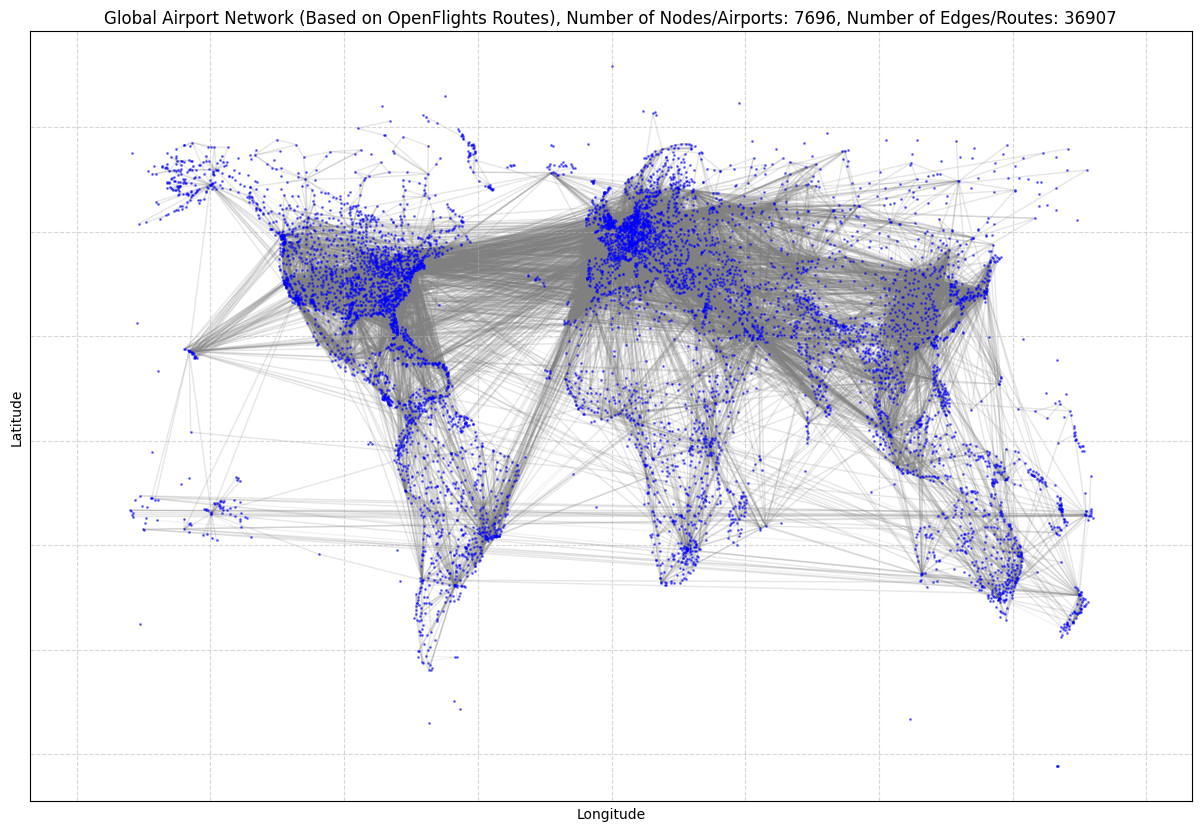

In [34]:
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(15, 10))

# Create a dictionary for positions based on longitude and latitude
pos = {node: (data['lon'], data['lat']) for node, data in G.nodes(data=True)}

# Draw nodes and edges
nx.draw_networkx_nodes(G, pos, node_size=1, node_color='blue', alpha=0.5)
nx.draw_networkx_edges(G, pos, arrows=False, edge_color='gray', alpha=0.1)

plt.title(f"Global Airport Network (Based on OpenFlights Routes), Number of Nodes/Airports: {G.number_of_nodes()}, Number of Edges/Routes: {G.number_of_edges()}")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [35]:
#Shows the unique pairs
unique_pairs = set()
for route in cleaned_route_list:
    try:
        pair = (int(route.source_airport_id), int(route.destination_aiport_id))
        unique_pairs.add(pair)
    except (ValueError, TypeError):
        continue

print(f"Number of cleaned routes: {len(cleaned_route_list)}")
print(f"Number of unique source-destination pairs: {len(unique_pairs)}")
print(f"Number of edges in G: {G.number_of_edges()}")

Number of cleaned routes: 67240
Number of unique source-destination pairs: 37274
Number of edges in G: 36907
